# Module 3 Lab: Linear Programming with PuLP (expanded)

Working through the lab example from the presentation, then trying a few extra things on my own to make sure I actually get how PuLP works before starting the assignment.

In [4]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 4.4 MB/s  0:00:03 eta 0:00:01


In [5]:
import pulp

lp_501 = pulp.LpProblem("LP_501", pulp.LpMaximize)

In [6]:
x = pulp.LpVariable('x', lowBound=0, cat='Continuous')
y = pulp.LpVariable('y', lowBound=2, cat='Continuous')

In [7]:
#Maximize Z = 4x + 3Y
lp_501 += 4 * x + 3 * y, "Z"

#Constraints

#2y <= 25-x
lp_501 += 2*y <= 25-x

#4y >= 2x-8
lp_501 += 4*y >= 2*x-8

#y<=2x-5
lp_501 += y <= 2*x-5

In [8]:
lp_501

LP_501:
MAXIMIZE
4*x + 3*y + 0
SUBJECT TO
_C1: x + 2 y <= 25

_C2: - 2 x + 4 y >= -8

_C3: - 2 x + y <= -5

VARIABLES
x Continuous
2 <= y Continuous

In [9]:
lp_501.variables()

[x, y]

In [10]:
lp_501.solve()
pulp.LpStatus[lp_501.status]

#Possible status codes
#Not Solved: Status prior to solving the problem.
#Optimal: An optimal solution has been found.
#Infeasible: There are no feasible solutions (e.g. if you set the constraints x <= 1 and x >=2).
#Unbounded: The constraints are not bounded, maximising the solution will tend towards infinity (e.g. if the only constraint was x >= 3).
#Undefined: The optimal solution may exist but may not have been found.

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/guna/projects/research/Semester-1-MSAAI-501-AIML/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/365e20d1fb914d2ba24fa5fc65ae7b87-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/365e20d1fb914d2ba24fa5fc65ae7b87-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 17 RHS
At line 21 BOUNDS
At line 23 ENDATA
Problem MODEL has 3 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 3 (0) rows, 2 (0) columns and 6 (0) elements
0  Obj 6 Primal inf 3.4999999 (1) Dual inf 6.9999998 (2)
0  Obj 6 Primal inf 3.4999999 (1) Dual inf 1e+10 (1)
2  Obj 73.75
Optimal - objective value 73.75
Optimal objective 73.75 - 2 iterations time 0.002
Option fo

'Optimal'

In [11]:
print(x.varValue)
print(y.varValue)
print(pulp.value(lp_501.objective))  # also printing Z so I can see the max profit, not just x and y

14.5
5.25
73.75


## Extra 1: Plotting the feasible region

The solver just spits out numbers, so I wanted to actually *see* what's going on. Since we only have 2 variables I can plot each constraint as a line and shade the region where all of them hold at the same time. The optimal point should end up at a corner of that region (that's the whole idea behind LP -- the optimum is always at a vertex).

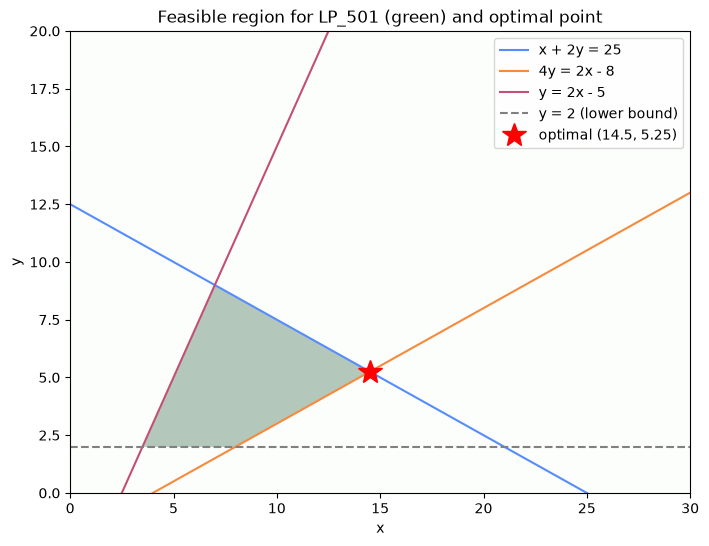

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Grid of x,y points to test the constraints on
xs = np.linspace(0, 30, 400)
ys = np.linspace(0, 20, 400)
X, Y = np.meshgrid(xs, ys)

# All constraints from the problem (plus the variable bounds)
feasible = (
    (2*Y <= 25 - X) &      # x + 2y <= 25
    (4*Y >= 2*X - 8) &     # 2x - 4y <= 8
    (Y <= 2*X - 5) &       # -2x + y <= -5
    (X >= 0) &
    (Y >= 2)               # y had lowBound=2
)

plt.figure(figsize=(8, 6))
# shade the feasible region
plt.imshow(feasible.astype(int), extent=(0, 30, 0, 20), origin='lower',
           cmap='Greens', alpha=0.3, aspect='auto')

# draw each constraint as a line
plt.plot(xs, (25 - xs)/2, label='x + 2y = 25')
plt.plot(xs, (2*xs - 8)/4, label='4y = 2x - 8')
plt.plot(xs, 2*xs - 5, label='y = 2x - 5')
plt.axhline(2, color='gray', linestyle='--', label='y = 2 (lower bound)')

# mark the optimal point the solver found
plt.plot(x.varValue, y.varValue, 'r*', markersize=18,
         label=f'optimal ({x.varValue}, {y.varValue})')

plt.xlim(0, 30); plt.ylim(0, 20)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Feasible region for LP_501 (green) and optimal point')
plt.legend(loc='upper right')
plt.show()

So the green area is every (x, y) combo that satisfies all the constraints, and the red star (the solver's answer) sits exactly on a corner where two constraint lines cross. Makes sense -- if I slide the profit line 4x + 3y up as far as it can go, the last point it touches is that vertex.

## Extra 2: What if x and y have to be integers?

The lab used `cat='Continuous'`, so we got fractional answers. But in a lot of real problems (like producing units of a product) you can't make half a unit. Switching to `cat='Integer'` turns this into an integer program. I want to see how much the answer changes -- important thing I learned: you can't just round the continuous answer, the rounded point might not even be feasible.

In [13]:
lp_int = pulp.LpProblem("LP_501_integer", pulp.LpMaximize)

xi = pulp.LpVariable('xi', lowBound=0, cat='Integer')
yi = pulp.LpVariable('yi', lowBound=2, cat='Integer')

lp_int += 4*xi + 3*yi, "Z"
lp_int += 2*yi <= 25 - xi
lp_int += 4*yi >= 2*xi - 8
lp_int += yi <= 2*xi - 5

lp_int.solve()
print(pulp.LpStatus[lp_int.status])
print('xi =', xi.varValue)
print('yi =', yi.varValue)
print('Z  =', pulp.value(lp_int.objective))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/guna/projects/research/Semester-1-MSAAI-501-AIML/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/d0794c1549ea435a86c4b8ca87bfb4eb-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/d0794c1549ea435a86c4b8ca87bfb4eb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 21 RHS
At line 25 BOUNDS
At line 28 ENDATA
Problem MODEL has 3 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 73.75 - 0.00 seconds
Cgl0004I processed model has 3 rows, 2 columns (2 integer (0 of which binary)) and 6 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0012I Integer solution of -71 found by DiveCoefficient after 0 iteration

The integer solution gives a slightly lower Z than the continuous one, which makes sense: forcing integers just adds another restriction, so the objective can only stay the same or get worse. Also worth noticing the integer answer is not just the continuous answer rounded.

## Extra 3: Binary (yes/no) decision variables

The assignment has an "overtime" decision -- pay $500 for 20 extra machine hours, yes or no. That's a binary variable (`cat='Binary'`), so I'm practicing the pattern here on a smaller version of the lab problem.

Setup: same LP as before, but pretend the constraint `x + 2y <= 25` is a resource limit, and I can pay a fee of 15 (in Z units) to raise the limit from 25 to 40. Let `b = 1` if I pay for the upgrade, `b = 0` if not.

The trick is writing the constraint so it loosens only when b = 1:

`x + 2y <= 25 + 15*b`

and subtracting the fee in the objective:

`Z = 4x + 3y - 15*b`

Then the solver decides on its own whether the upgrade is worth it.

In [14]:
lp_bin = pulp.LpProblem("LP_501_upgrade", pulp.LpMaximize)

xb = pulp.LpVariable('xb', lowBound=0, cat='Continuous')
yb = pulp.LpVariable('yb', lowBound=2, cat='Continuous')
b  = pulp.LpVariable('b', cat='Binary')   # 1 = pay for the upgrade, 0 = don't

# objective: profit minus the upgrade fee (only charged when b = 1)
lp_bin += 4*xb + 3*yb - 15*b, "Z"

# resource limit goes from 25 to 40 when b = 1
lp_bin += xb + 2*yb <= 25 + 15*b

# same other constraints as before
lp_bin += 4*yb >= 2*xb - 8
lp_bin += yb <= 2*xb - 5

lp_bin.solve()
print(pulp.LpStatus[lp_bin.status])
print('xb =', xb.varValue)
print('yb =', yb.varValue)
print('b  =', b.varValue, '(1 means pay for the upgrade)')
print('Z  =', pulp.value(lp_bin.objective))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/guna/projects/research/Semester-1-MSAAI-501-AIML/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/0d8016f8df714e279cd4830bbf79f77e-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/0d8016f8df714e279cd4830bbf79f77e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 21 RHS
At line 25 BOUNDS
At line 28 ENDATA
Problem MODEL has 3 rows, 3 columns and 7 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 100 - 0.00 seconds
Cgl0004I processed model has 3 rows, 3 columns (1 integer (1 of which binary)) and 7 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution found of -100
Cbc0038I Relaxing continuous gives -1

In [15]:
# sanity check: force b = 0 and b = 1 manually and compare Z,
# to confirm the solver actually picked the better option
for forced in [0, 1]:
    m = pulp.LpProblem(f"check_b{forced}", pulp.LpMaximize)
    xc = pulp.LpVariable('xc', lowBound=0)
    yc = pulp.LpVariable('yc', lowBound=2)
    m += 4*xc + 3*yc - 15*forced
    m += xc + 2*yc <= 25 + 15*forced
    m += 4*yc >= 2*xc - 8
    m += yc <= 2*xc - 5
    m.solve(pulp.PULP_CBC_CMD(msg=0))
    print(f'b forced to {forced}: Z = {pulp.value(m.objective):.2f}')

b forced to 0: Z = 73.75
b forced to 1: Z = 100.00


The solver picked whichever option had the higher Z, which matches my manual check. This is exactly the structure I'll need for the assignment: extra machine hours that only exist if the binary variable is 1, with the cost subtracted from profit.

## Extra 4: Breaking the model on purpose (Infeasible status)

The status codes list mentions `Infeasible`, so I wanted to trigger it once so I recognize it if it happens by accident. If I demand y >= 20 on top of the original constraints, there's no point that satisfies everything (the feasible region in my plot never gets anywhere near y = 20).

In [16]:
lp_bad = pulp.LpProblem("LP_501_broken", pulp.LpMaximize)

xz = pulp.LpVariable('xz', lowBound=0)
yz = pulp.LpVariable('yz', lowBound=2)

lp_bad += 4*xz + 3*yz
lp_bad += 2*yz <= 25 - xz
lp_bad += 4*yz >= 2*xz - 8
lp_bad += yz <= 2*xz - 5
lp_bad += yz >= 20        # impossible on purpose

lp_bad.solve()
print(pulp.LpStatus[lp_bad.status])

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/guna/projects/research/Semester-1-MSAAI-501-AIML/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/a0328a0fb98c4627b4edfd740499fc91-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/d3/nhglz3qs7sggp0t2xt84rjvh0000gn/T/a0328a0fb98c4627b4edfd740499fc91-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 9 COLUMNS
At line 19 RHS
At line 24 BOUNDS
At line 26 ENDATA
Problem MODEL has 4 rows, 2 columns and 7 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve determined that the problem was infeasible with tolerance of 1e-08
Analysis indicates model infeasible or unbounded
0  Obj 6 Primal inf 21.5 (2) Dual inf 6.9999998 (2)
0  Obj 6 Primal inf 21.5 (2) Dual inf 1.5e+10 (2)
3  Obj 55 Primal inf 11 (1)
Primal infeas

Good -- it says `Infeasible` instead of crashing. Lesson: always check `pulp.LpStatus[problem.status]` before trusting `varValue`, because an infeasible model can still return numbers that mean nothing.

## Takeaways

- Continuous vs Integer vs Binary is just the `cat=` argument on `LpVariable`.
- A binary variable can turn a constraint on/off (extra capacity) and add a cost to the objective at the same time.
- Always check the solver status first, then read the variable values with `.varValue` and the objective with `pulp.value(problem.objective)`.